#### Autoencoder

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Global settings for Assignment Task 1
SEED = 42
LR = 0.001  # Using same value for all rules 
THRESHOLD = 0.0005 # Stopping criterion
MAX_EPOCHS = 1000

def set_reproducibility():
    """Sets the seed for everything to ensure consistent output."""
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    # Generator for data shuffling to avoid random.shuffle
    g = torch.Generator()
    g.manual_seed(SEED)
    return g

# Initialize the generator
data_gen = set_reproducibility()

In [2]:
class Task1Model(nn.Module):
    def __init__(self, input_size=36, output_size=5):
        super(Task1Model, self).__init__()
        # MLFFNN with 20 and 10 nodes [cite: 5]
        self.fc1 = nn.Linear(input_size, 20)
        self.fc2 = nn.Linear(20, 10)
        self.fc3 = nn.Linear(10, output_size)
        self.tanh = nn.Tanh() # Activation: Tanh [cite: 6]

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        return self.fc3(x) # Raw logits for CrossEntropyLoss [cite: 7]

# Save a "Master State" to ensure every optimizer starts with the same weights 
master_model = Task1Model()
torch.save(master_model.state_dict(), 'initial_weights.pth')

In [3]:
def train_pattern_mode(optimizer_name, inputs, targets):

    torch.manual_seed(42)
    np.random.seed(42)
    local_gen = torch.Generator()
    local_gen.manual_seed(42)
    
    # 1. Setup Model and Optimizer
    model = Task1Model()
    model.load_state_dict(torch.load('initial_weights.pth')) # Ensure same initial weights 
    
    criterion = nn.CrossEntropyLoss() # Loss function: Cross-entropy [cite: 7]
    
    if optimizer_name == "Delta Rule":
        optimizer = optim.SGD(model.parameters(), lr=LR)
    elif optimizer_name == "Generalized Delta":
        optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    elif optimizer_name == "AdaGrad":
        optimizer = optim.Adagrad(model.parameters(), lr=LR)
    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=LR)
    elif optimizer_name == "AdaM":
        optimizer = optim.Adam(model.parameters(), lr=LR)

    loss_history = []
    past_error = 1e9
    
    # 2. Training Loop
    for epoch in range(MAX_EPOCHS):
        epoch_error = 0
        # Smart Shuffling: Use fixed generator to be consistent across runs
        indices = torch.randperm(len(inputs), generator=local_gen).tolist()
        
        for i in indices:
            x, y = inputs[i].unsqueeze(0), targets[i].unsqueeze(0)
            
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            
            epoch_error += loss.item()
        
        avg_loss = epoch_error / len(inputs)
        loss_history.append(avg_loss)
        
        # Stopping Criterion: Change in average error below threshold [cite: 10]
        if abs(past_error - avg_loss) < THRESHOLD:
            print(f"Converged at Epoch {epoch+1}")
            break
        past_error = avg_loss
        
    return model, loss_history


def show_results(model, inputs, targets, title):
    """Generates Accuracy and Confusion Matrices for the report."""
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
        # Get the index of the max log-probability (predicted class)
        _, preds = torch.max(outputs, 1)
        
        # Calculate Accuracy
        correct = (preds == targets).sum().item()
        total = targets.size(0)
        accuracy = (correct / total) * 100
        
    print(f"\n--- {title} Results ---")
    print(f"Accuracy: {accuracy:.2f}%")
    
    # Generate and display Confusion Matrix 
    cm = confusion_matrix(targets.cpu(), preds.cpu())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix: {title}\nAccuracy: {accuracy:.2f}%")
    plt.show()
    
    return accuracy

In [33]:
import pandas as pd
import torch

def load_assignment_data(data_path, label_path):
    # Load CSVs
    data_df = pd.read_csv(data_path, header=None) # Use header=None if no column names
    labels_df = pd.read_csv(label_path, header=None)
    
    # Convert to PyTorch Tensors
    # Inputs should be float32 for the Linear layers
    inputs = torch.tensor(data_df.values, dtype=torch.float32)
    
    # Labels for CrossEntropyLoss must be Long (integers) 
    # and 1D (shape: [N] instead of [N, 1])
    labels = torch.tensor(labels_df.values, dtype=torch.long).squeeze()
    
    # Check if labels are 0-indexed (e.g., 0, 1, 2, 3, 4 for 5 classes)
    # If your labels are 1-5, subtract 1: labels = labels - 1
    
    return inputs, labels

data_path_train = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task1\train_data.csv"
data_path_train_labels = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task1\train_label.csv"

data_path_test = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task1\test_data.csv"
data_path_test_labels = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task1\test_label.csv"



# Usage:
# train_inputs, train_targets = load_assignment_data('train_data.csv', 'train_label.csv')
# test_inputs, test_targets = load_assignment_data('test_data.csv', 'test_label.csv')

train_inputs, train_targets = load_assignment_data(data_path_train, data_path_train_labels)
test_inputs, test_targets = load_assignment_data(data_path_test, data_path_test_labels)

Converged at Epoch 52


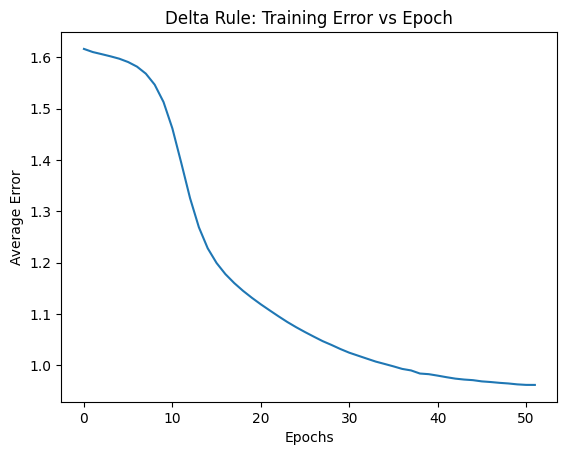


--- Delta Rule (Train) Results ---
Accuracy: 55.70%


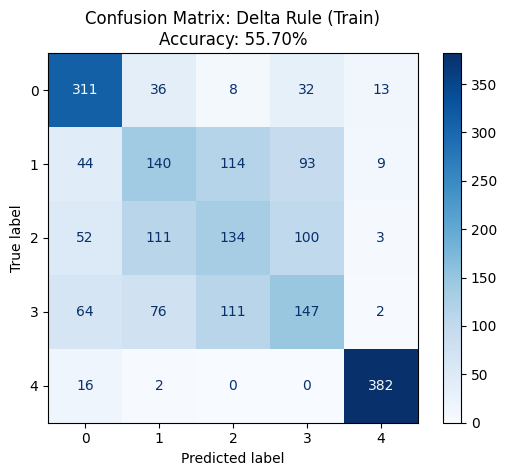


--- Delta Rule (Test) Results ---
Accuracy: 54.60%


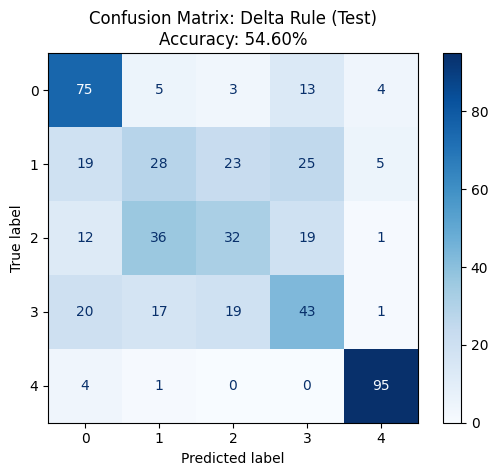

In [21]:
# --- RUN BLOCK FOR DELTA RULE ---
model_delta, loss_delta = train_pattern_mode("Delta Rule", train_inputs, train_targets)

# (a) Plot Average Error vs Epoch 
plt.plot(loss_delta)
plt.title("Delta Rule: Training Error vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Average Error")
plt.show()

# (b) Confusion Matrices and Accuracies 
acc_delta_train = show_results(model_delta, train_inputs, train_targets, "Delta Rule (Train)")
acc_delta_test = show_results(model_delta, test_inputs, test_targets, "Delta Rule (Test)")

Converged at Epoch 26


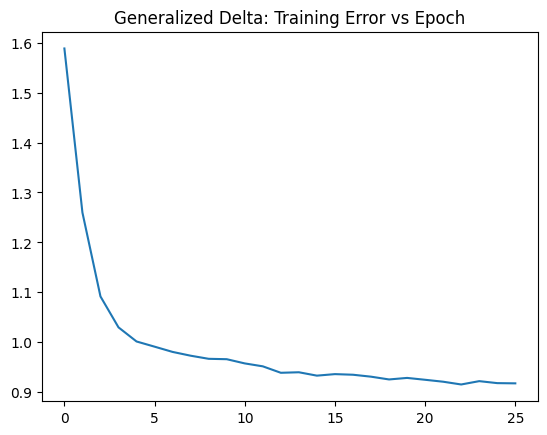


--- Generalized Delta (Train) Results ---
Accuracy: 61.50%


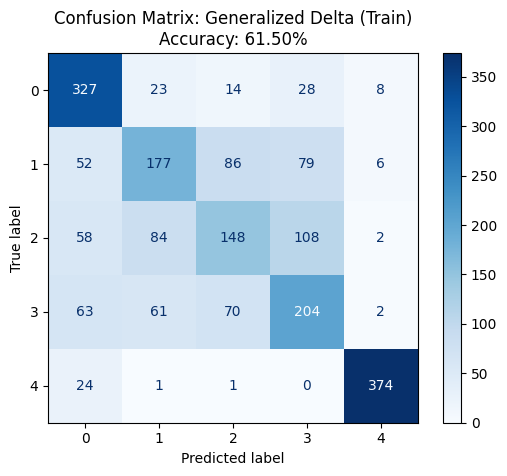


--- Generalized Delta (Test) Results ---
Accuracy: 57.00%


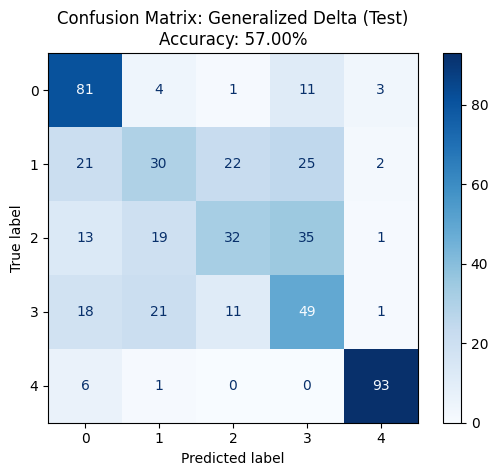

In [22]:
# --- RUN BLOCK FOR GENERALIZED DELTA ---
model_gdelta, loss_gdelta = train_pattern_mode("Generalized Delta", train_inputs, train_targets)

plt.plot(loss_gdelta)
plt.title("Generalized Delta: Training Error vs Epoch")
plt.show()

acc_gdelta_train = show_results(model_gdelta, train_inputs, train_targets, "Generalized Delta (Train)")
acc_gdelta_test = show_results(model_gdelta, test_inputs, test_targets, "Generalized Delta (Test)")

running gen delta again for confirmation

Converged at Epoch 26


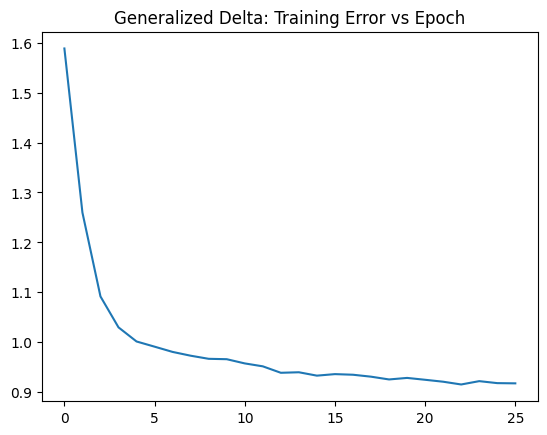


--- Generalized Delta (Train) Results ---
Accuracy: 61.50%


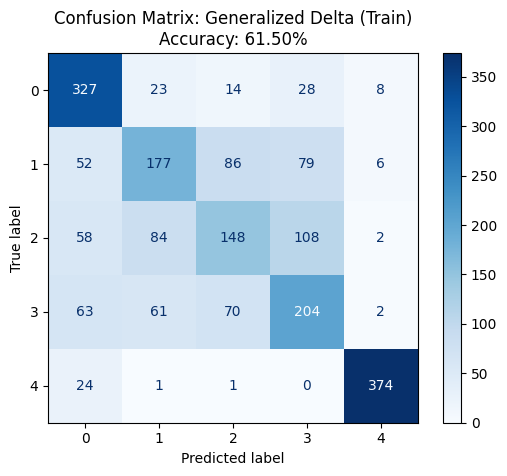


--- Generalized Delta (Test) Results ---
Accuracy: 57.00%


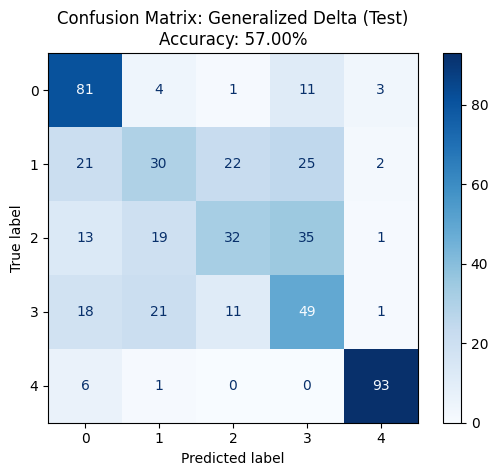

In [28]:
# --- RUN BLOCK FOR GENERALIZED DELTA ---
model_gdelta, loss_gdelta = train_pattern_mode("Generalized Delta", train_inputs, train_targets)

plt.plot(loss_gdelta)
plt.title("Generalized Delta: Training Error vs Epoch")
plt.show()

acc_gdelta_train = show_results(model_gdelta, train_inputs, train_targets, "Generalized Delta (Train)")
acc_gdelta_test = show_results(model_gdelta, test_inputs, test_targets, "Generalized Delta (Test)")

Converged at Epoch 169


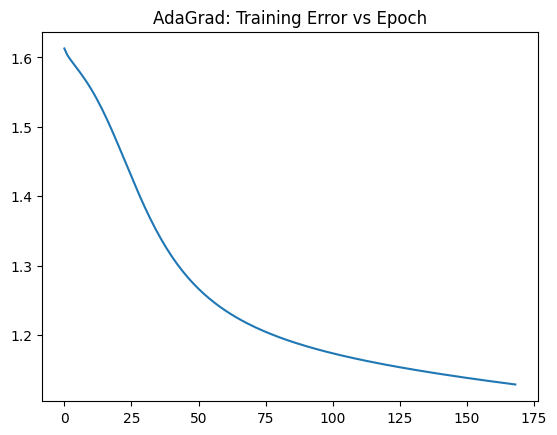


--- AdaGrad (Train) Results ---
Accuracy: 50.60%


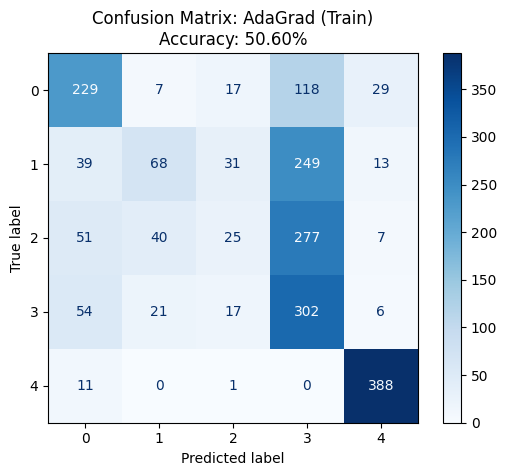


--- AdaGrad (Test) Results ---
Accuracy: 48.00%


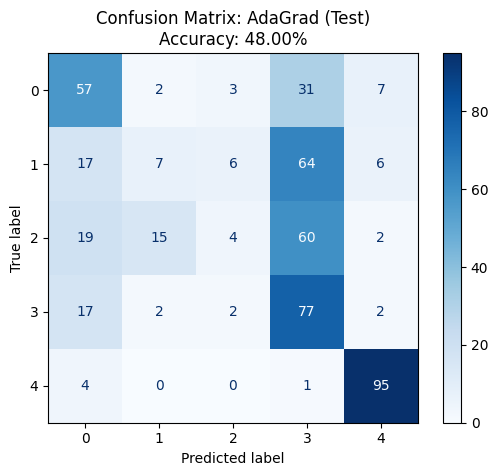

In [25]:
# --- RUN BLOCK FOR ADAGRAD ---
model_adagrad, loss_adagrad = train_pattern_mode("AdaGrad", train_inputs, train_targets)

plt.plot(loss_adagrad)
plt.title("AdaGrad: Training Error vs Epoch")
plt.show()

acc_adagrad_train = show_results(model_adagrad, train_inputs, train_targets, "AdaGrad (Train)")
acc_adagrad_test = show_results(model_adagrad, test_inputs, test_targets, "AdaGrad (Test)")

Converged at Epoch 22


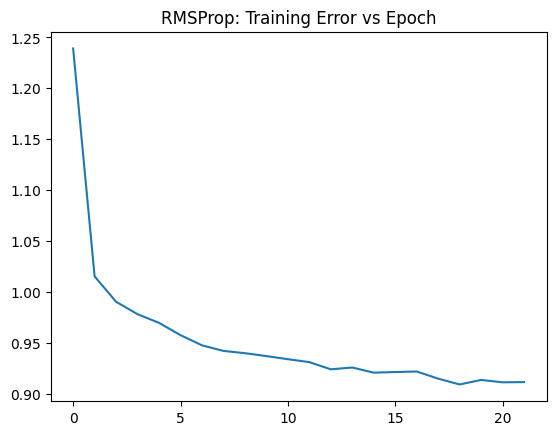


--- RMSProp (Train) Results ---
Accuracy: 61.60%


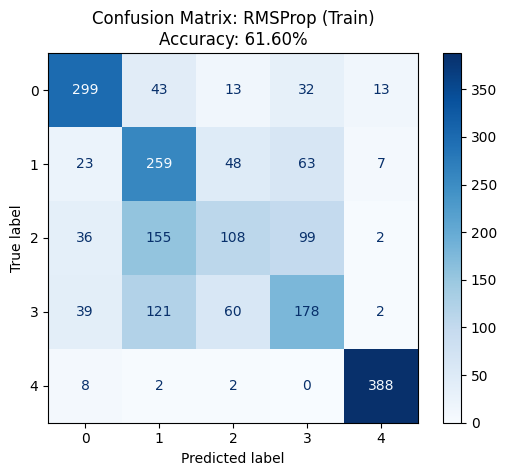


--- RMSProp (Test) Results ---
Accuracy: 58.20%


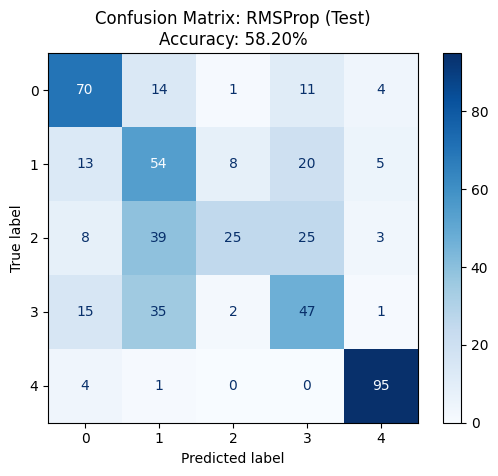

In [24]:
# --- RUN BLOCK FOR RMSPROP ---
model_rmsprop, loss_rmsprop = train_pattern_mode("RMSProp", train_inputs, train_targets)

plt.plot(loss_rmsprop)
plt.title("RMSProp: Training Error vs Epoch")
plt.show()

acc_rmsprop_train = show_results(model_rmsprop, train_inputs, train_targets, "RMSProp (Train)")
acc_rmsprop_test = show_results(model_rmsprop, test_inputs, test_targets, "RMSProp (Test)")

Converged at Epoch 26


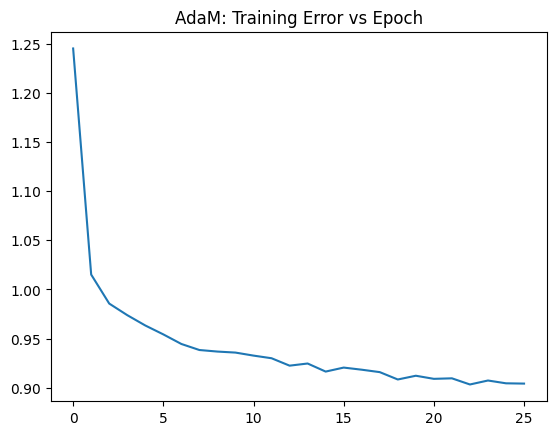


--- AdaM (Train) Results ---
Accuracy: 61.30%


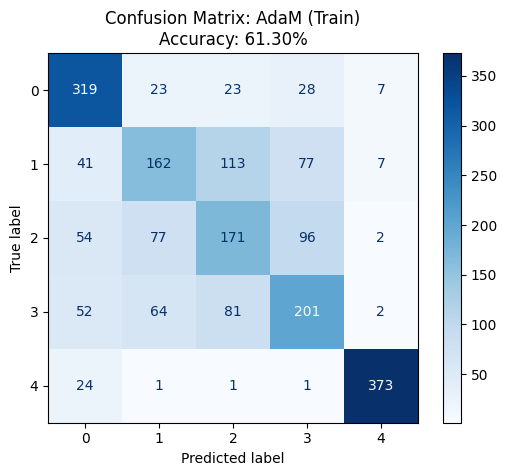


--- AdaM (Test) Results ---
Accuracy: 56.20%


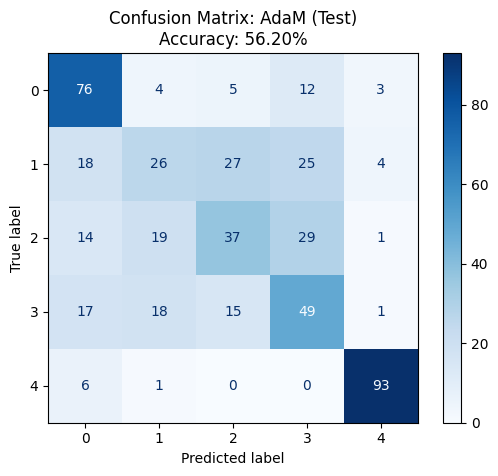

In [23]:
# --- RUN BLOCK FOR ADAM ---
model_adam, loss_adam = train_pattern_mode("AdaM", train_inputs, train_targets)

plt.plot(loss_adam)
plt.title("AdaM: Training Error vs Epoch")
plt.show()

acc_adam_train = show_results(model_adam, train_inputs, train_targets, "AdaM (Train)")
acc_adam_test = show_results(model_adam, test_inputs, test_targets, "AdaM (Test)")

In [26]:
import pandas as pd

# Creating the data list from your existing variables
summary_list = []
results_map = {
    "Delta Rule": (loss_delta, model_delta),
    "Generalized Delta": (loss_gdelta, model_gdelta),
    "AdaGrad": (loss_adagrad, model_adagrad),
    "RMSProp": (loss_rmsprop, model_rmsprop),
    "AdaM": (loss_adam, model_adam)
}

for name, (loss_hist, model_obj) in results_map.items():
    # Calculate Final Accuracies using the models you already trained
    model_obj.eval()
    with torch.no_grad():
        train_preds = torch.max(model_obj(train_inputs), 1)[1]
        train_acc = (train_preds == train_targets).sum().item() / len(train_targets) * 100
        
        test_preds = torch.max(model_obj(test_inputs), 1)[1]
        test_acc = (test_preds == test_targets).sum().item() / len(test_targets) * 100

    summary_list.append({
        "Weight Update Rule": name,
        "Epochs to Converge": len(loss_hist),
        "Final Avg Error": f"{loss_hist[-1]:.6f}",
        "Train Accuracy": f"{train_acc:.2f}%",
        "Test Accuracy": f"{test_acc:.2f}%"
    })

# Display the table
df_task1 = pd.DataFrame(summary_list)
print("TASK 1 COMPARISON TABLE")
print(df_task1.to_string(index=False))

TASK 1 COMPARISON TABLE
Weight Update Rule  Epochs to Converge Final Avg Error Train Accuracy Test Accuracy
        Delta Rule                  52        0.961743         55.70%        54.60%
 Generalized Delta                  26        0.917565         61.50%        57.00%
           AdaGrad                 169        1.128566         50.60%        48.00%
           RMSProp                  22        0.911382         61.60%        58.20%
              AdaM                  26        0.904095         61.30%        56.20%


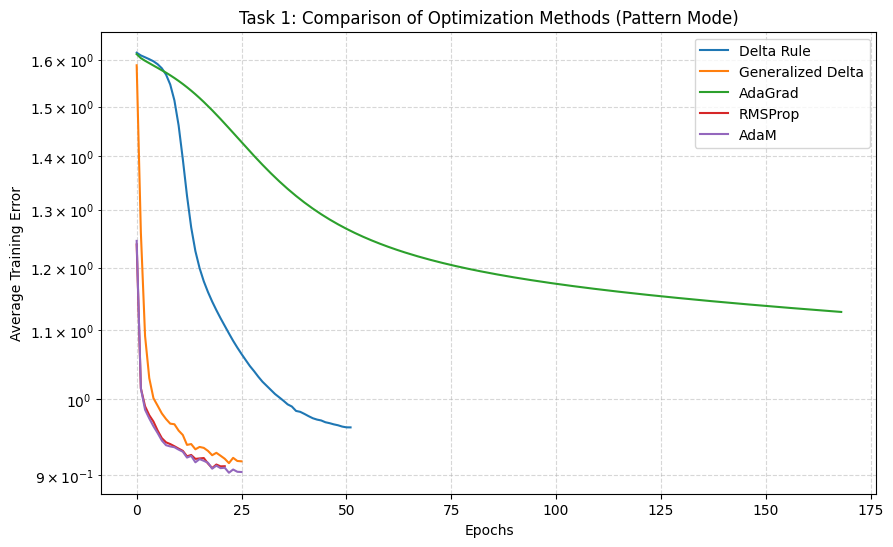

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(loss_delta, label="Delta Rule")
plt.plot(loss_gdelta, label="Generalized Delta")
plt.plot(loss_adagrad, label="AdaGrad")
plt.plot(loss_rmsprop, label="RMSProp")
plt.plot(loss_adam, label="AdaM")

plt.title("Task 1: Comparison of Optimization Methods (Pattern Mode)")
plt.xlabel("Epochs")
plt.ylabel("Average Training Error")
plt.yscale('log') # Log scale helps see the separation between fast optimizers
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.show()

Converged at Epoch 26


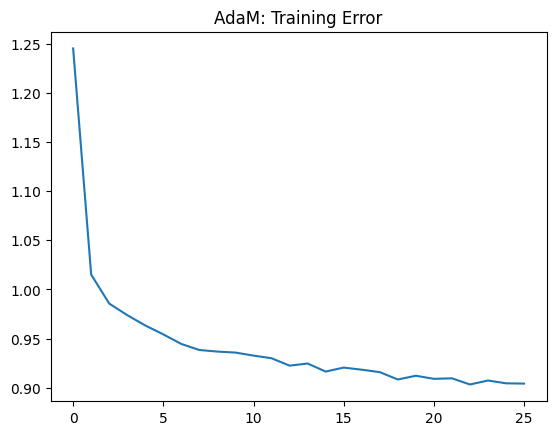

Training Confusion Matrix:


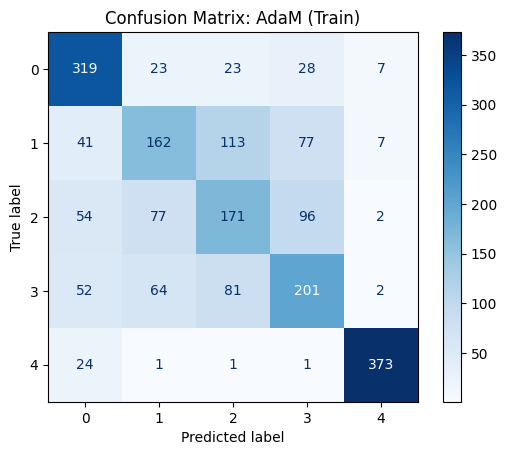

Test Confusion Matrix:


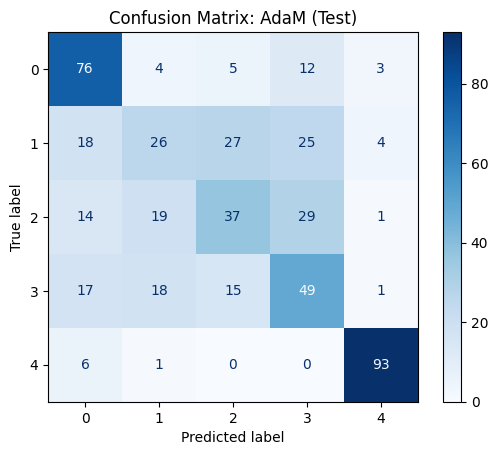

In [ ]:
# --- RUN BLOCK FOR ADAM ---
model_adam, loss_adam = train_pattern_mode("AdaM", train_inputs, train_targets)

# (a) Plot of average error vs Epoch [cite: 14]
plt.plot(loss_adam)
plt.title("AdaM: Training Error")
plt.show()

# (b) Confusion Matrices [cite: 14]
print("Training Confusion Matrix:")
show_results(model_adam, train_inputs, train_targets, "AdaM (Train)")
print("Test Confusion Matrix:")
show_results(model_adam, test_inputs, test_targets, "AdaM (Test)")

In [31]:
data_path_train_2 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task2\train_data.csv"
data_path_train_labels_2 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task2\train_label.csv"

data_path_test_2 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task2\test_data.csv"
data_path_test_labels_2 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task2\test_label.csv"



# Usage:
# train_inputs, train_targets = load_assignment_data('train_data.csv', 'train_label.csv')
# test_inputs, test_targets = load_assignment_data('test_data.csv', 'test_label.csv')

train_inputs_2, train_targets_2 = load_assignment_data(data_path_train_2, data_path_train_labels_2)
test_inputs_2, test_targets_2 = load_assignment_data(data_path_test_2, data_path_test_labels_2)

In [32]:
# Load your data first
# train_inputs_2, train_targets_2 = load_assignment_data('train_data_2.csv', 'train_label_2.csv')

print(f"Number of training samples: {train_inputs.shape[0]}")
print(f"Number of features (Input Size): {train_inputs.shape[1]}")
print(f"Number of classes: {len(torch.unique(train_targets))}")

# Batch Size Recommendation:
# If samples > 1000, use 32 or 64. 
# If samples < 500, use 16.

Number of training samples: 2000
Number of features (Input Size): 36
Number of classes: 5


In [34]:
class Task2Model(nn.Module):
    def __init__(self, norm_type="None", input_size=36, output_size=5):
        super(Task2Model, self).__init__()
        self.norm_type = norm_type
        
        # Layers
        self.fc1 = nn.Linear(input_size, 20)
        self.fc2 = nn.Linear(20, 10)
        self.fc3 = nn.Linear(10, output_size)
        self.tanh = nn.Tanh()

        # Normalization Layers
        if norm_type == "LayerNorm":
            self.ln1 = nn.LayerNorm(20)
            self.ln2 = nn.LayerNorm(10)
        elif norm_type == "BatchNorm":
            self.bn1 = nn.BatchNorm1d(20)
            self.bn2 = nn.BatchNorm1d(10)

    def forward(self, x):
        # Layer 1
        x = self.tanh(self.fc1(x))
        if self.norm_type == "LayerNorm": x = self.ln1(x)
        elif self.norm_type == "BatchNorm": x = self.bn1(x) # Post-activation
        
        # Layer 2
        x = self.tanh(self.fc2(x))
        if self.norm_type == "LayerNorm": x = self.ln2(x)
        elif self.norm_type == "BatchNorm": x = self.bn2(x) # Post-activation
        
        return self.fc3(x)

# Save initial weights for Task 2 to ensure same starting point
master_model_t2 = Task2Model(norm_type="None")
torch.save(master_model_t2.state_dict(), 'initial_weights_t2.pth')

In [ ]:
# batch normalization post activation- logic
# # Layer 1
# x = self.fc1(x)        # 1. Linear
# x = self.tanh(x)       # 2. Activation (Tanh)
# x = self.bn1(x)        # 3. Normalization (Post-activation)

In [35]:
from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 32 # Common for mini-batch mode

def train_minibatch_mode(norm_type, inputs, targets):
    # Reset seeds for total reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    
    # Setup Data
    dataset = TensorDataset(inputs, targets)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True) # Shuffle per epoch
    
    model = Task2Model(norm_type=norm_type)
    # Load base weights (ignoring norm layer weights which init to 1s and 0s anyway)
    model.load_state_dict(torch.load('initial_weights_t2.pth'), strict=False)
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []
    past_error = 1e9

    for epoch in range(MAX_EPOCHS):
        epoch_error = 0
        model.train()
        
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_error += loss.item() * batch_x.size(0)
            
        avg_loss = epoch_error / len(inputs)
        loss_history.append(avg_loss)
        
        if abs(past_error - avg_loss) < THRESHOLD:
            print(f"{norm_type} Converged at Epoch {epoch+1}")
            break
        past_error = avg_loss
        
    return model, loss_history

None Converged at Epoch 24


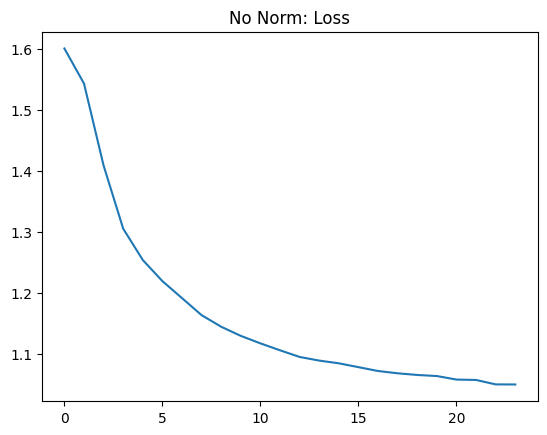


--- No Norm (Train) Results ---
Accuracy: 57.85%


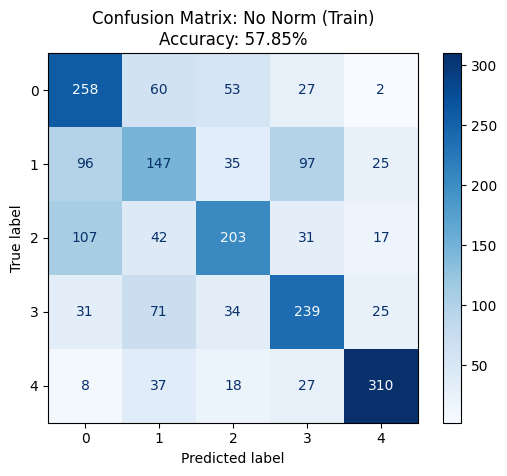


--- No Norm (Test) Results ---
Accuracy: 56.20%


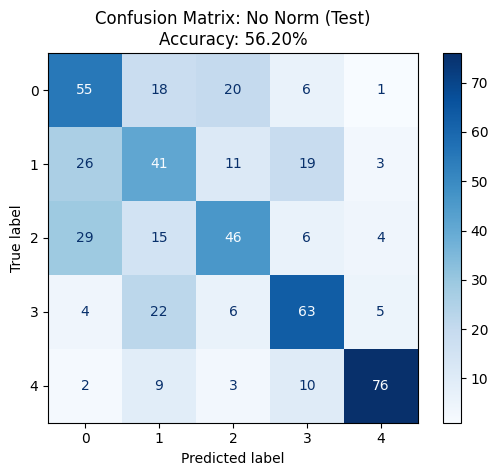

In [44]:
# No normalization
model_none, loss_none = train_minibatch_mode("None", train_inputs_2, train_targets_2)
plt.plot(loss_none); plt.title("No Norm: Loss"); plt.show()

acc_none_train = show_results(model_none, train_inputs_2, train_targets_2, "No Norm (Train)")
acc_none_test = show_results(model_none, test_inputs_2, test_targets_2, "No Norm (Test)")

LayerNorm Converged at Epoch 34


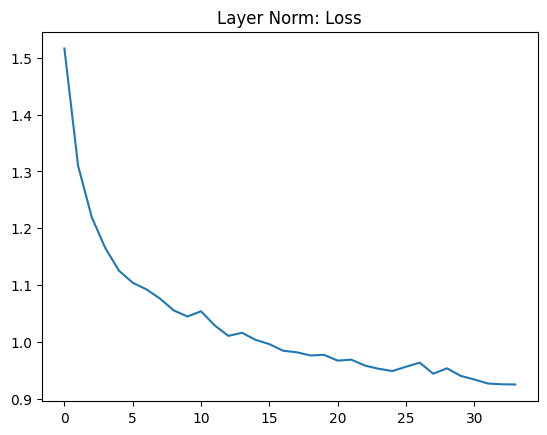


--- Layer Norm (Train) Results ---
Accuracy: 64.15%


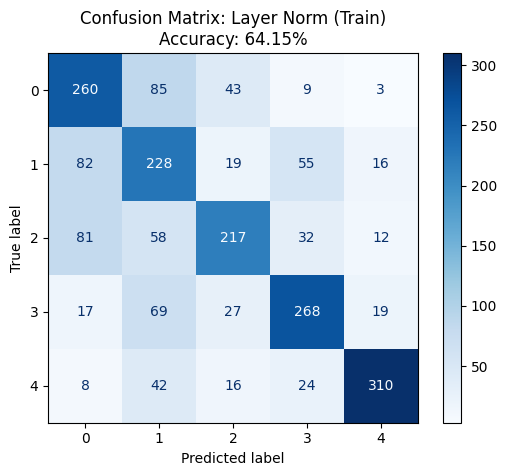


--- Layer Norm (Test) Results ---
Accuracy: 60.20%


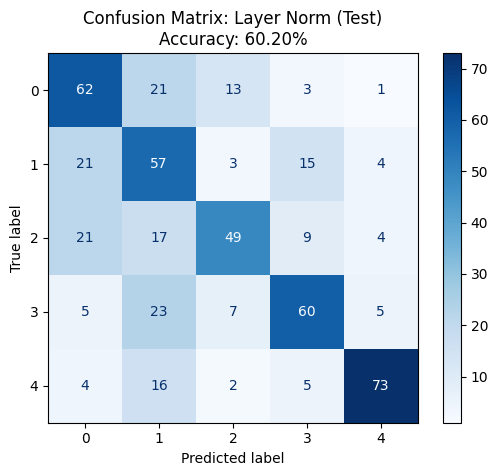

In [45]:
# Layer normalization
model_ln, loss_ln = train_minibatch_mode("LayerNorm", train_inputs_2, train_targets_2)
plt.plot(loss_ln); plt.title("Layer Norm: Loss"); plt.show()

acc_ln_train = show_results(model_ln, train_inputs_2, train_targets_2, "Layer Norm (Train)")
acc_ln_test = show_results(model_ln, test_inputs_2, test_targets_2, "Layer Norm (Test)")

BatchNorm Converged at Epoch 57


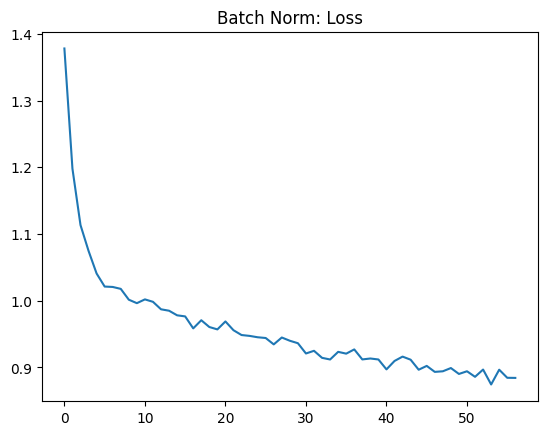


--- Batch Norm (Train) Results ---
Accuracy: 68.70%


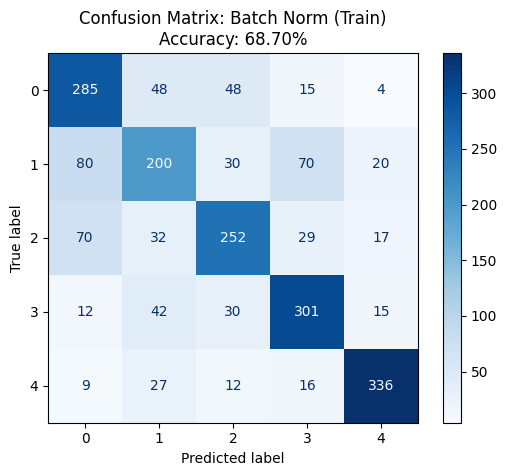


--- Batch Norm (Test) Results ---
Accuracy: 59.80%


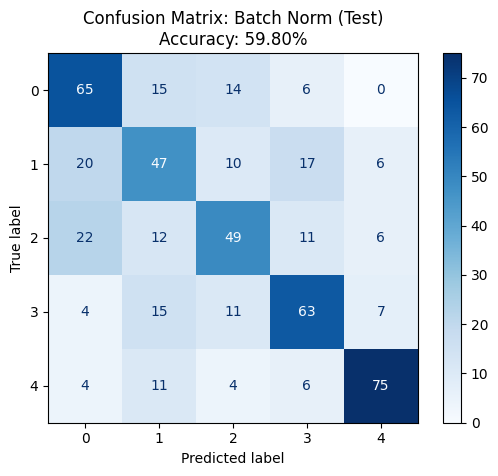

In [46]:
# Batch normalization (post activation)
model_bn, loss_bn = train_minibatch_mode("BatchNorm", train_inputs_2, train_targets_2)
plt.plot(loss_bn); plt.title("Batch Norm: Loss"); plt.show()

acc_bn_train = show_results(model_bn, train_inputs_2, train_targets_2, "Batch Norm (Train)")
acc_bn_test = show_results(model_bn, test_inputs_2, test_targets_2, "Batch Norm (Test)")

In [47]:
t2_summary = [
    ("No Normalization", len(loss_none), acc_none_train, acc_none_test),
    ("Layer Normalization", len(loss_ln), acc_ln_train, acc_ln_test),
    ("Batch Normalization", len(loss_bn), acc_bn_train, acc_bn_test)
]

df_t2 = pd.DataFrame(t2_summary, columns=["Method", "Epochs", "Train Acc", "Test Acc"])
print("\n--- TASK 2 FINAL COMPARISON ---")
print(df_t2.to_string(index=False))


--- TASK 2 FINAL COMPARISON ---
             Method  Epochs  Train Acc  Test Acc
   No Normalization      24      57.85      56.2
Layer Normalization      34      64.15      60.2
Batch Normalization      57      68.70      59.8


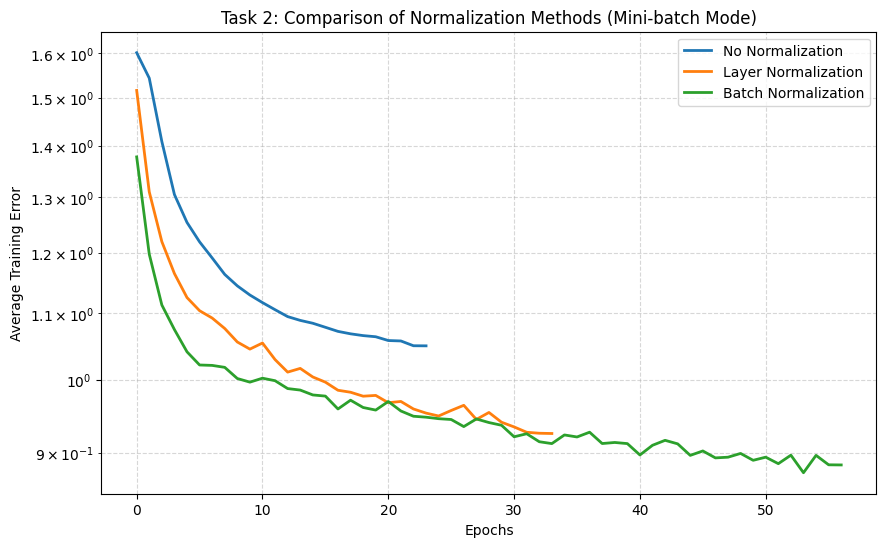

In [48]:
plt.figure(figsize=(10, 6))

# Plotting each loss history
plt.plot(loss_none, label="No Normalization", linewidth=2)
plt.plot(loss_ln, label="Layer Normalization", linewidth=2)
plt.plot(loss_bn, label="Batch Normalization", linewidth=2)

# Formatting the plot
plt.title("Task 2: Comparison of Normalization Methods (Mini-batch Mode)")
plt.xlabel("Epochs")
plt.ylabel("Average Training Error")
plt.yscale('log') # Log scale is recommended to see the fine detail at lower error values
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.show()

#### TASK 3

In [49]:
from sklearn.decomposition import PCA

In [220]:
# The 5-Layer Autoencoder (AANN)
class AANN_5Layer(nn.Module):
    def __init__(self, input_dim, bottleneck_dim):
        super(AANN_5Layer, self).__init__()
        # Symmetric 5-layer: Input -> H1 -> Bottleneck -> H2 -> Output
        # h_dim = int((input_dim + bottleneck_dim) / 1.5)
        h_dim = int((input_dim + bottleneck_dim) / 2.0)
        # h_dim = int((input_dim + bottleneck_dim) / 3.0)
        
        # Encoder: Input -> H1 -> Bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h_dim),
            nn.Tanh(),
            nn.Linear(h_dim, bottleneck_dim),
            nn.Tanh()
        )
        # Decoder: Bottleneck -> H2 -> Output
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, h_dim),
            nn.Tanh(),
            nn.Linear(h_dim, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def get_features(self, x):
        with torch.no_grad():
            return self.encoder(x)



class DFNN_Task3(nn.Module):
    def __init__(self, input_dim, l1, l2, l3, num_classes=5):
        super(DFNN_Task3, self).__init__()
        # Calculate the same h_dims used in the AANNs
        # self.h1_dim = int((input_dim + l1) / 1.5)
        # self.h2_dim = int((l1 + l2) / 1.5)
        self.h1_dim = int((input_dim + l1) / 2.0)
        self.h2_dim = int((l1 + l2) / 2.0)
        # self.h1_dim = int((input_dim + l1) / 3.0)
        # self.h2_dim = int((l1 + l2) / 3.0)
        
        
        # Expanded layers to match the 5-layer AANN structure
        self.layer1_a = nn.Linear(input_dim, self.h1_dim)
        self.layer1_b = nn.Linear(self.h1_dim, l1)
        
        self.layer2_a = nn.Linear(l1, self.h2_dim)
        self.layer2_b = nn.Linear(self.h2_dim, l2)
        
        self.layer3 = nn.Linear(l2, l3)
        self.output = nn.Linear(l3, num_classes)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.layer1_a(x))
        x = self.tanh(self.layer1_b(x))
        x = self.tanh(self.layer2_a(x))
        x = self.tanh(self.layer2_b(x))
        x = self.tanh(self.layer3(x))
        return self.output(x)

In [221]:
def train_aann(input_data, bottleneck_dim, epochs=200, batch_size=32, lr=0.001, threshold = 1e-7):
    """
    Trains a 5-layer AANN using Mini-batch AdaM.
    input_data: Tensor of inputs (Unlabeled)
    bottleneck_dim: The size of the linear bottleneck (L1 or L2)
    """
    torch.manual_seed(42) # Ensure reproducibility for each AE training
    
    # 1. Initialize Model
    input_dim = input_data.shape[1]
    model = AANN_5Layer(input_dim, bottleneck_dim)
    
    # 2. Setup Optimizer and Loss
    # Using AdaM as per Task 3 requirements
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss() # AANNs minimize reconstruction error
    
    # 3. Create DataLoader for Mini-batch mode
    dataset = TensorDataset(input_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model.train()
    loss_history = []
    past_loss = 1e9
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in loader:
            x_batch = batch[0]
            
            # Forward pass
            optimizer.zero_grad()
            reconstruction = model(x_batch)
            loss = criterion(reconstruction, x_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * x_batch.size(0)
        
        avg_loss = epoch_loss / len(input_data)
        loss_history.append(avg_loss)
        
        # Stopping Criterion: Stop if change in loss is negligible
        # if abs(past_loss - avg_loss) < 1e-7:
        if abs(past_loss - avg_loss) < threshold:
            print(f"AE (Bottleneck={bottleneck_dim}) converged at epoch {epoch+1}")
            break
        past_loss = avg_loss
            
    return model

In [222]:
def get_pca_info(train_data, variance_threshold=0.95):
    # Fit PCA on the raw training data
    pca = PCA(random_state=42)
    pca.fit(train_data.detach().cpu().numpy())
    
    # Calculate cumulative variance to find L3 size
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    l3_dim = np.argmax(cumsum >= variance_threshold) + 1
    
    # Extract the top components (weights)
    # Shape will be (l3_dim, 36)
    l3_weights = torch.tensor(pca.components_[:l3_dim], dtype=torch.float32)
    
    print(f"L3 dimension for {variance_threshold*100}% variance: {l3_dim}")
    return l3_dim, l3_weights


In [223]:
def assemble_task3_model(ae1, ae2, l3_w, input_dim, l1, l2, l3):
    model = DFNN_Task3(input_dim, l1, l2, l3)
    with torch.no_grad():
        # AE1 transfer (2 layers)
        model.layer1_a.weight.copy_(ae1.encoder[0].weight)
        model.layer1_a.bias.copy_(ae1.encoder[0].bias)
        model.layer1_b.weight.copy_(ae1.encoder[2].weight)
        model.layer1_b.bias.copy_(ae1.encoder[2].bias)
        
        # AE2 transfer (2 layers)
        model.layer2_a.weight.copy_(ae2.encoder[0].weight)
        model.layer2_a.bias.copy_(ae2.encoder[0].bias)
        model.layer2_b.weight.copy_(ae2.encoder[2].weight)
        model.layer2_b.bias.copy_(ae2.encoder[2].bias)
        
        # PCA transfer
        model.layer3.weight.copy_(l3_w)
        model.layer3.bias.zero_()
    return model

In [224]:
def train_dfnn_task3(model, inputs, targets, lr=0.001, batch_size=32, threshold = 1e-6):
    """
    Fine-tunes the assembled model or trains a random model using labeled data.
    """
    # Setup Data
    dataset = TensorDataset(inputs, targets)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []
    past_error = 1e9
    
    model.train()
    for epoch in range(200): # MAX_EPOCHS
        epoch_error = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_error += loss.item() * batch_x.size(0)
            
        avg_loss = epoch_error / len(inputs)
        loss_history.append(avg_loss)
        
        # Stopping Criterion
        # if abs(past_error - avg_loss) < 1e-6:
        if abs(past_error - avg_loss) < threshold:
            print(f"Converged at Epoch {epoch+1}")
            break
        past_error = avg_loss
        
    return model, loss_history

In [225]:
def load_data(file_path, is_label=False):
    df = pd.read_csv(file_path)
    if is_label:
        return torch.tensor(df.values.flatten(), dtype=torch.long)
    return torch.tensor(df.values, dtype=torch.float32)

data_path_train_3 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task3\training_data_set_19_labeled_data.csv"
data_path_train_labels_3 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task3\training_data_set_19_labeled_labels.csv"
data_path_train_unlabelled_3 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task3\training_data_set_19_unlabeled.csv"


data_path_test_3 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task3\testing_data_set_19_data.csv"
data_path_test_labels_3 = r"C:\Users\naray\Desktop\Sem 8\CS6910 FoDL\team19_assignment1\task3\testing_data_set_19_labels.csv"

# Load Labeled Training Data
train_labeled_inputs_3 = load_data(data_path_train_3)
train_labeled_targets_3 = load_data(data_path_train_labels_3, is_label=True)

# Load Unlabeled Training Data (For AE Pre-training)
train_unlabeled_inputs_3 = load_data(data_path_train_unlabelled_3)

# Load Test Data
test_inputs_3 = load_data(data_path_test_3)
test_targets_3 = load_data(data_path_test_labels_3, is_label=True)

print(f"Data Loaded Successfully!")
print(f"Unlabeled: {train_unlabeled_inputs_3.shape} | Labeled: {train_labeled_inputs_3.shape} | Test: {test_inputs_3.shape}")

Data Loaded Successfully!
Unlabeled: torch.Size([1749, 36]) | Labeled: torch.Size([749, 36]) | Test: torch.Size([249, 36])


In [ ]:
# # A. Get L3 info from Training Data
# L3, pca_weights = get_pca_info(train_labeled_inputs_3, 0.95)

# # B. Train Autoencoders (Unlabeled)
# ae1 = train_aann(train_unlabeled_inputs_3, bottleneck_dim=25)
# feat1 = ae1.get_features(train_unlabeled_inputs_3)
# ae2 = train_aann(feat1, bottleneck_dim=15)

L3 dimension for 95.0% variance: 31
AE (Bottleneck=25) converged at epoch 46


In [226]:
import torch
import numpy as np
from sklearn.decomposition import PCA

# 1. Combine Labeled and Unlabeled data for a "Global" PCA
# Shape will be (Total Samples, 36)
entire_dataset = torch.cat((train_labeled_inputs_3, train_unlabeled_inputs_3), dim=0)

# 2. Fit PCA on the entire raw dataset
pca_global = PCA(random_state=42)
pca_global.fit(entire_dataset.cpu().numpy())

# 3. Find L3 for 95% variance
cumsum = np.cumsum(pca_global.explained_variance_ratio_)
L3 = np.argmax(cumsum >= 0.95) + 1
print("L3 is ", L3)

# 4. Enforce the strict bottleneck: 36 > L1 > L2 > L3
# If L3 is very high (like 31), the gap is small. 
# We use float division then floor to ensure distinct steps if possible.
gap = (36 - L3) / 3
L1 = int(36 - gap)
L2 = int(36 - 2 * gap)

# Safety check: if gap is too small, force a minimum step of 1
if L1 >= 36: L1 = 35
if L2 >= L1: L2 = L1 - 1
if L3 >= L2: L3 = L2 - 1

print(f"Total Samples used for PCA: {entire_dataset.shape[0]}")
print(f"Calculated Dimensions: Input(36) > L1({L1}) > L2({L2}) > L3({L3})")

L3 is  31
Total Samples used for PCA: 2498
Calculated Dimensions: Input(36) > L1(34) > L2(32) > L3(31)


In [227]:
# Train AE1 (36 -> L1)
print(f"Training AE1 (36 -> {L1})...")
ae1 = train_aann(train_unlabeled_inputs_3, bottleneck_dim=L1)

# Train AE2 (L1 -> L2)
print(f"Training AE2 ({L1} -> {L2})...")
feat1 = ae1.get_features(train_unlabeled_inputs_3)
ae2 = train_aann(feat1, bottleneck_dim=L2)

Training AE1 (36 -> 34)...
AE (Bottleneck=34) converged at epoch 92
Training AE2 (34 -> 32)...
AE (Bottleneck=32) converged at epoch 104


In [228]:
# 1. Extract features from the pre-trained AE2
with torch.no_grad():
    feat2_for_l3 = ae2.get_features(ae1.get_features(train_labeled_inputs_3))

# 2. Run PCA on these features to get the L3 weights
# Note: n_components is the L3 we found in Step 1
pca_l3 = PCA(n_components=L3, random_state=42)
pca_l3.fit(feat2_for_l3.cpu().numpy())

# 3. These weights will be (L3 x L2)
l3_weights = torch.tensor(pca_l3.components_, dtype=torch.float32)

print(f"L3 Weights Shape: {l3_weights.shape} (Matches Layer 3 requirements)")

L3 Weights Shape: torch.Size([31, 32]) (Matches Layer 3 requirements)


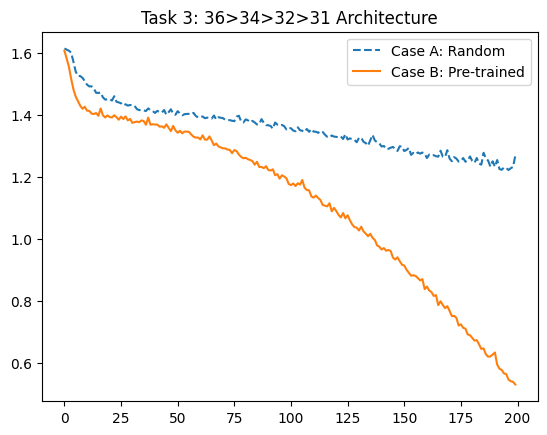

In [229]:
# --- CASE B: Assemble and Fine-tune ---
model_b = assemble_task3_model(ae1, ae2, l3_weights, 36, L1, L2, L3)
model_b, loss_b = train_dfnn_task3(model_b, train_labeled_inputs_3, train_labeled_targets_3)

# --- CASE A: Random Baseline ---
torch.manual_seed(42)
model_a = DFNN_Task3(36, L1, L2, L3)
model_a, loss_a = train_dfnn_task3(model_a, train_labeled_inputs_3, train_labeled_targets_3)

# --- Visualization ---
plt.plot(loss_a, label="Case A: Random", linestyle='--')
plt.plot(loss_b, label="Case B: Pre-trained")
plt.title(f"Task 3: {36}>{L1}>{L2}>{L3} Architecture")
plt.legend()
plt.show()

In [230]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model_task3(model, inputs, targets, title="Confusion Matrix"):
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        # Calculate Accuracy
        correct = (predicted == targets).sum().item()
        accuracy = (correct / targets.size(0)) * 100
        
        # Generate Confusion Matrix
        cm = confusion_matrix(targets.cpu().numpy(), predicted.cpu().numpy())
        
        # Plotting
        fig, ax = plt.subplots(figsize=(6, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(targets.cpu().numpy()))
        disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
        ax.set_title(f"{title}\nAccuracy: {accuracy:.2f}%")
        plt.show()
        
    return accuracy

--- Case A: Random Initialization Results ---


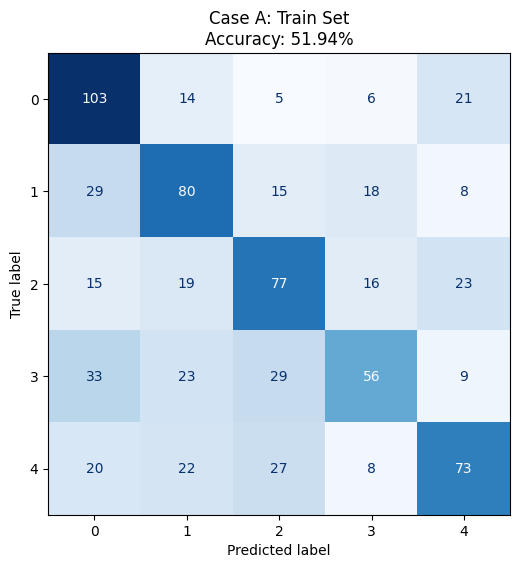

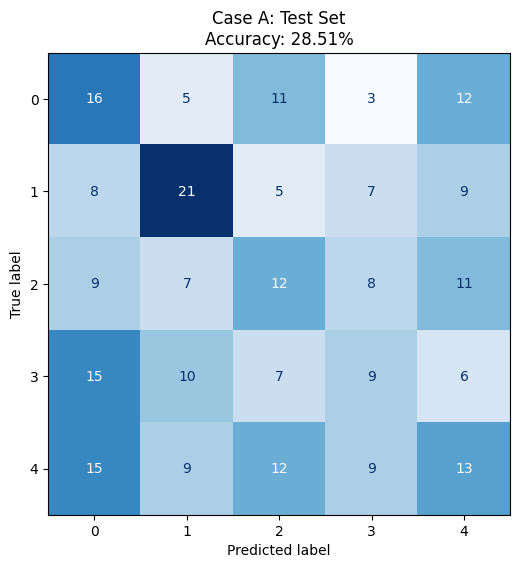

Case A - Final Train Accuracy: 51.94%
Case A - Final Test Accuracy: 28.51%


In [231]:
print("--- Case A: Random Initialization Results ---")
# Training Set Performance
acc_a_train = evaluate_model_task3(model_a, train_labeled_inputs_3, train_labeled_targets_3, "Case A: Train Set")

# Testing Set Performance
acc_a_test = evaluate_model_task3(model_a, test_inputs_3, test_targets_3, "Case A: Test Set")

print(f"Case A - Final Train Accuracy: {acc_a_train:.2f}%")
print(f"Case A - Final Test Accuracy: {acc_a_test:.2f}%")

--- Case B: Pre-trained + Fine-tuned Results ---


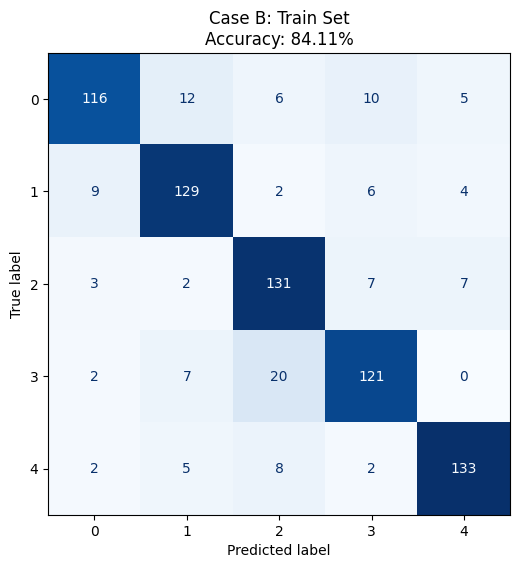

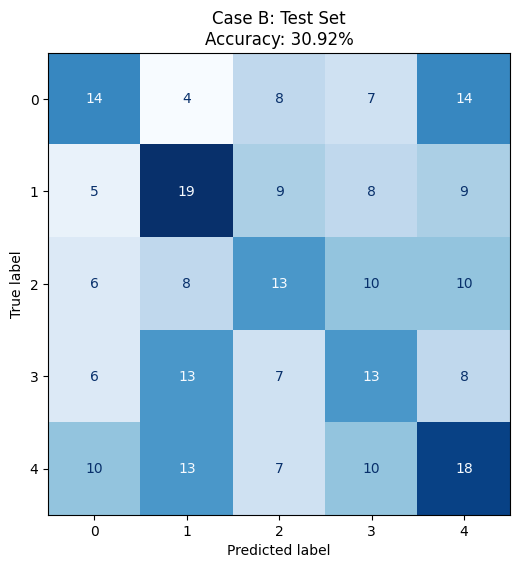

Case B - Final Train Accuracy: 84.11%
Case B - Final Test Accuracy: 30.92%


In [232]:
print("--- Case B: Pre-trained + Fine-tuned Results ---")
# Training Set Performance
acc_b_train = evaluate_model_task3(model_b, train_labeled_inputs_3, train_labeled_targets_3, "Case B: Train Set")

# Testing Set Performance
acc_b_test = evaluate_model_task3(model_b, test_inputs_3, test_targets_3, "Case B: Test Set")

print(f"Case B - Final Train Accuracy: {acc_b_train:.2f}%")
print(f"Case B - Final Test Accuracy: {acc_b_test:.2f}%")

In [234]:
summary_data = {
    "Metric": ["Train Accuracy", "Test Accuracy", "Epochs to Converge"],
    "Case A (Random)": [f"{acc_a_train:.2f}%", f"{acc_a_test:.2f}%", len(loss_a)],
    "Case B (Pre-trained)": [f"{acc_b_train:.2f}%", f"{acc_b_test:.2f}%", len(loss_b)]
}

summary_df = pd.DataFrame(summary_data)
print("\nFINAL TASK 3 COMPARISON")
print("="*30)
print(summary_df.to_string(index=False))


FINAL TASK 3 COMPARISON
            Metric Case A (Random) Case B (Pre-trained)
    Train Accuracy          51.94%               84.11%
     Test Accuracy          28.51%               30.92%
Epochs to Converge             200                  200
